# INTRODUCTION

## Domain Specific Area

Finding fake news is an important problem in today's digital age, where the internet is the main source of information for millions of people. The fast spread of false information, often called "fake news," has been linked to many problems in society, such as public health issues, political manipulation, and civil disorder (Faisal A. Alshuwaier, 2025). Since Facebook, Twitter, YouTube, and other social media sites are now the main way that people get news, it can be hard to tell the difference between real news and fake news. The way that algorithms are used on social media sites often favors participation over truth. This can make it easier for false information to spread without meaning to (Soroush Vosoughi, 2018). Fake news usually has lies or twisted facts in them that are meant to trick people for reasons like making money, changing people's minds about politics, or causing social unrest (Reid Priedhorsky, 2014).

Because fake news is becoming more common, researchers have started to use machine learning and natural language processing (NLP) more often to make automated systems that can find fake news. These systems look at patterns in the text of articles to see if the information is probably real or made up. For this, statistics models like Logistic Regression and Naive Bayes and deep learning models like LSTM are often used (Junming Liu, 2017). A broad review of the field shows that these models, ranging from traditional to deep learning, are the most popular and well-researched methods for this job. Each one has a unique strength when it comes to working with different kinds of language data (Faisal A. Alshuwaier, 2025).

There are a lot of problems that come up when trying to spot fake news. To begin, false news stories can be passed off as real ones by copying the format and wording of real news. Second, there is so much material online that manual verification is not possible which highlights the need of automated solutions (Amin, 2025). Text classification models that have been trained on big datasets of real and fake news stories can find small details that show the difference between real and fake news (Faisal A. Alshuwaier, 2025).We look at and compare several models for finding fake news in a dataset, such as Logistic Regression, Naive Bayes, and LSTM (Yexin Tian, 2025). Empirical comparisons have shown that Logistic Regression can be very accurate in these kinds of tasks often better than Naive Bayes. LSTM based models can hit even higher performance levels (Mallavarapu, 2025). The goal is to find out which way works best for dealing with these problems and correctly sorting news stories into groups based on how real they are.

## Objectives of the Project

The goal of this project is to build a strong system that can tell when news is fake. It will use a range of machine learning models to do this. The goals are:

### 1. Compare at Different Classification Models:
Logistic Regression, Naive Bayes,and LSTM (Long Short-Term Memory) are three models that will be trained and tested as part of the project. Naive Bayes and Logistic Regression are older models (Faisal A. Alshuwaier, 2025). LSTM is a newer deep learning model that is able to understand the linear nature of text data.

### 2. Preparing Text for Model Readiness:
Data preprocessing is an important step in any machine learning job, particularly in natural language processing (NLP). This includes things like tokenization, removing stop words, and lowercasing (Razzaq, 2025). The project will use Python's nltk tool to do preprocessing. Also, TF-IDF (Term Frequency-Inverse Document Frequency) is used to turn text data into numbers for the statistical models, and padded sequences will be used for the LSTM model (Amin, 2025). These methods make sure that the models can handle the text data well.

### 3. Evaluate Model Performance:
A variety of performance metrics, such as accuracy, precision, recall, and F1-score, is used by the project to evaluate the models (Moses Daniel Kwaknat, 2025). These numbers will be figured out for each model so that we can see how well they can tell the difference between real and fake news. The confusion matrix will also be used to see how well the models can tell the difference between fake and real stories.

### 4. Provides Insights for Model Selection:
By comparing the results from the baseline models (Logistic Regression, Naive Bayes) with the advanced model (LSTM), the project aims to provide insights on which model performs best for fake news detection. This comparison will show which method is best in terms of performance and speed, as well as which ones have drawbacks. In high- dimensional text classification tasks like fake news spotting, Logistic Regression usually works better than Naive Bayes (Amin, 2025). Research also shows that hybrid models that combine LSTM with other architectures can achieve the best overall results (Ramesh Kumar Ayyasamy, 2018).

# Getting all the libraries needed

In [1]:
#importing libraries for data processing,visualization and machine learning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
pip install tensorflow

...
Note: you may need to restart the kernel to use updated packages.


In [2]:
#for text processing and NLP tasks
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

In [3]:
#deep learning libraries (LSTM model)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

In [4]:
#NLTK resources
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

True

# Loading the Dataset

In [5]:
def load_data(filepath='FakeNewsNet.csv'):
    #reading the CSV file into a DataFrame
    df = pd.read_csv(filepath)

    print("=========== LOADING DATA ===========")
    #displaying the number of rows and columns of the dataset
    print(f"Dataset shape: {df.shape}")

    #showing the distribution of the 'real' column
    print(f"\nClass distribution:")
    print(df['real'].value_counts())

    #deleting rows with missing title
    df = df.dropna(subset=['title'])
    print(f"\nAfter removing missing titles: {len(df)} rows")

    #displaying the first 5 rows of the dataset
    print("\nHead of the dataset (first 5 rows):")
    display(df.head())

    #displaying the last 5 rows of the dataset
    print("\nTail of the dataset (last 5 rows):")
    display(df.tail())

    #returning the cleaned DataFrame
    return df

## Dataset Description

For this research, the FakeNewsNet dataset, which is accessible on Kaggle, is a great option for a number of reasons. Since the news items in this dataset are marked as either "real" or "fake," it works perfectly for training and testing binary classification models for fake news detection. The collection has 5 columns and 23,196 rows, which are as follows:

- **title**: The article's headline.
- **text**: The article's complete text.
- **subject**: The category or domain of the article (e.g., politics, business, technology).
- **date**: The publication date of the story.
- **real**: A binary designation that indicates if an article is authentic (1) or fraudulent (0).

Dataset: (Golovin, 2022)

Reasons for picking this dataset for the project:

### 1. Fair and Varied Data:
The FakeNewsNet dataset has a lot of different news stories about many topics, like politics, business, and entertainment (Ramesh Kumar Ayyasamy, 2018). This range makes it easier to teach models that can work with all sorts of material. Also, the collection has stories from both real and fake news sources. This lets the model learn how to tell the two classes apart. This is very important because it means that the models are tested on a wide range of real news stories. This makes the data useful for different kinds of fake news.

### 2. Real-World Usefulness:
Finding fake news is a problem in many areas, including politics, health, and entertainment. Since it has stories from different categories, the FakeNewsNet dataset makes finding fake news a more difficult and realistic task. When models are trained on this wide-ranging dataset, the outcome will be a model that is more capable of handling real-world tasks where news articles from various areas need to be properly classified.

### 3. Size and Structure:
The dataset has a lot of examples (23,196 rows), which is great for teaching machine learning models. Large datasets help avoid overfitting, especially when using deep learning models like LSTM, which need a lot of data to generalize well (Ramesh Kumar Ayyasamy, 2018). The data is organized into a table and contains text-based features. This makes it easy to use common preprocessing methods like vectorization, stemming, and tokenization.

### 4. Direct Link to Problems with Detecting Fake News:
The collection is made for finding fake news, so it directly helps with the problem that this project wants to solve. The project can train, test, and compare models at telling the difference between real and fake news right on the dataset labeled "real" or "fake." The labels in the dataset are a great match for the project's goals, which makes it easy to use supervised learning models (Ramesh Kumar Ayyasamy, 2018).

# Cleaning text for Statistical Model

In [6]:
def preprocess_for_statistical_model(text):
    #initializing stemmer and stop words
    stemmer = PorterStemmer()
    stop_words = set(stopwords.words('english'))

    #converting to lowercase
    text = str(text).lower()

    #tokenize the text
    tokens = word_tokenize(text)

    #removing stop words and apply stemming
    processed_tokens = [stemmer.stem(token) for token in tokens if token.isalpha() and token not in stop_words and len(token) > 2]

    #joining the tokens back into a single string
    return ' '.join(processed_tokens)

In [7]:
def apply_statistical_preprocessing(df):
    print("=========== PREPROCESSING FOR STATISTICAL MODEL ===========")

    #applying the preprocessing function to the title
    df['processed_title'] = df['title'].apply(preprocess_for_statistical_model)

    #storing the initial number of rows
    initial_rows = len(df)

    #removing rows where the processed title is empty or only contains whitespace
    df = df[df['processed_title'].str.strip() != '']

    #storing the final number of rows after removal of empty titles
    final_rows = len(df)

    #printing how many rows were removed due to empty processed text
    print(f"After preprocessing, {final_rows} rows remain.")
    if initial_rows > final_rows:
        print(f"Removed {initial_rows - final_rows} rows with empty processed text.")

    #showing a sample of the original and processed titles for comparison
    print("\nSample preprocessing results (Original → Processed):")
    print("-" * 70)
    for i in range(min(1, len(df))):
        idx = df.index[i]
        print(f"\nExample {i+1}:")
        #displaying first 80 characters of original and processed title
        print(f"Original: {df.loc[idx, 'title'][:80]}...")
        print(f"Processed: {df.loc[idx, 'processed_title'][:80]}...")

    #calculating and displaying the average word count for original and processed titles
    avg_length_original = df['title'].str.split().str.len().mean()
    avg_length_processed = df['processed_title'].str.split().str.len().mean()

    print("\n" + "-" * 70)
    print(f"Average words per title (original): {avg_length_original:.2f}")
    print(f"Average words per title (processed): {avg_length_processed:.2f}")

    #calculating and displaying the percentage reduction in title length
    print(f"Reduction: {((avg_length_original - avg_length_processed) / avg_length_original * 100):.2f}%")

    return df

In [8]:
def create_tfidf_features(X_train, X_test, max_features=5000):
    print("=========== CREATING TF-IDF FEATURES ===========")

    #initializing the TF-IDF vectorizer with specified parameters
    vectorizer = TfidfVectorizer(max_features=max_features, ngram_range=(1, 2), min_df=2, max_df=0.8)

    #fitting the vectorizer on the training data and transforming it into TF-IDF features
    X_train_tfidf = vectorizer.fit_transform(X_train)

    #transforming the test data into TF-IDF features
    X_test_tfidf = vectorizer.transform(X_test)

    #printing the shape of the transformed training and test data
    print(f"Training data shape: {X_train_tfidf.shape}")
    print(f"Test data shape: {X_test_tfidf.shape}")

    return X_train_tfidf, X_test_tfidf, vectorizer

# Cleaning text for Embedding Model

In [9]:
def preprocess_for_embedding_model(text):
    #converting to string and lowercasing
    text = str(text).lower()

    #tokenizing the text into individual words using word_tokenize
    tokens = word_tokenize(text)

    #filtering out nonalphabetic tokens
    tokens = [token for token in tokens if token.isalpha()]

    #joining the tokens back into a single string with space
    return ' '.join(tokens)

In [10]:
def apply_embedding_preprocessing(df):
    print("=========== PREPROCESSING FOR EMBEDDING MODEL ===========")

    #applying the preprocessing function to the title
    df['embedding_title'] = df['title'].apply(preprocess_for_embedding_model)

    #printing the number of rows processed
    print(f"Embedding preprocessing complete. {len(df)} rows processed.")

    #showing a sample of the original and processed titles
    print("\nSample preprocessing results (Original → Processed):")
    print("-" * 70)
    for i in range(min(1, len(df))):
        idx = df.index[i]
        print(f"\nExample {i+1}:")
        #displaying first 80 characters of original and processed title
        print(f"Original: {df.loc[idx, 'title'][:80]}...")
        print(f"Processed: {df.loc[idx, 'embedding_title'][:80]}...")

    #calculating and displaying the average word count for original and processed titles
    avg_length_original = df['title'].str.split().str.len().mean()
    avg_length_processed = df['embedding_title'].str.split().str.len().mean()

    print("\n" + "-" * 70)
    print(f"Average words per title (original): {avg_length_original:.2f}")
    print(f"Average words per title (processed): {avg_length_processed:.2f}")

    #calculating and displaying the percentage reduction in title length
    print(f"Reduction: {((avg_length_original - avg_length_processed) / avg_length_original * 100):.2f}%")

    return df

In [11]:
def create_sequences(X_train, X_test, max_words=10000, max_len=50):
    print("===========CREATING WORD SEQUENCES===========")

    #initialize tokenizer and fit on training data
    tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
    tokenizer.fit_on_texts(X_train)

    #converting texts to sequences of integers
    X_train_seq = tokenizer.texts_to_sequences(X_train)
    X_test_seq = tokenizer.texts_to_sequences(X_test)

    #pad sequences to have the same length
    X_train_padded = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
    X_test_padded = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')

    print(f"Training sequences shape: {X_train_padded.shape}")
    print(f"Test sequences shape: {X_test_padded.shape}")

    return X_train_padded, X_test_padded, tokenizer

## Data Preprocessing

Data preparation is an important step in getting unformatted text into a shape that machine learning models can use. The goal is to help the model learn useful patterns and make correct guesses by cleaning up the text and making it uniform. Naive Bayes is a statistical model and LSTM is an embedding model. The following are the steps done before using each model.

### 1.Naive Bayes Preprocessing
Naive Bayes needs clean data to do good statistical analysis. The following steps are done beforehand:
- **Lowercasing:** Changing all writing to lowercase makes things uniform, so "Apple" and "apple" are seen as the same word.
- **Tokenization:** This breaks the text up into single words, or "tokens," which takes apart the organization and puts the focus on each word.
- **Stopword Removal:** Words that don't add much sense, like "the" and "is," are taken out because they are used often.
- **Stemming:** This reduces words to their most basic form (for example, "running" becomes "run"), which makes the language easier.

These steps clean up the text so that the model can focus on the most important words for classification. This helps with performance and generalization.

### 2.LSTM preprocessing
For LSTM models, the same kind of preprocessing is done but it focuses on keeping meaningful tokens and capturing the sequential connections in the text:
- **Lowercasing:** Makes sure all words are the same, so "Machine" and "machine" are seen as the same.
- **Tokenization:** This is like Naive Bayes, but for LSTM, the sequence context of words is the main point.
- **Filtering Non-Alphabetic Tokens:** Only alphabetic tokens are kept, and numbers and characters are removed because they might not give helpful information for finding fake news.
- **Final Join:** After they are done being processed, the tokens are joined back into one string so the model can read it.

This method of cleaning the text helps the LSTM model get a better sense of the context and how the words in the sequence are related to each other. This makes it easier for the model to pick up on subtle trends.

### 3.Making Sequences for LSTM
After preprocessing, LSTM models need to be given numerical sequences so they can handle them:
- **Tokenization:** The number of words determines the integer that represents them.
- **Padding:** The sequences are padded to make sure that all inputs are the same length. This is needed for LSTM models.
- **Maximum Sequence Length:** The length of sequences is kept within limits so that the model isn't confused by overly long sequences and shorter ones don't lose important features.

Following these steps makes sure that the LSTM model can work with text data of different lengths without losing important features.

# Splitting data into train and test sets

In [12]:
def split_data(df, test_size=0.2, random_state=42):
    print("=========== SPLITTING DATA ===========")

    #defining the features and target variable
    X_statistical = df['processed_title']
    X_embedding = df['embedding_title']
    y = df['real'].values

    #splitting the data into training and test sets
    X_stat_train, X_stat_test, X_emb_train, X_emb_test, y_train, y_test = train_test_split(
        X_statistical, X_embedding, y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )

    #printing the number of training and test samples
    print(f"Training samples: {len(X_stat_train)}")
    print(f"Test samples: {len(X_stat_test)}")

    #returning the split data
    return {
        'X_stat_train': X_stat_train,
        'X_stat_test': X_stat_test,
        'X_emb_train': X_emb_train,
        'X_emb_test': X_emb_test,
        'y_train': y_train,
        'y_test': y_test
    }

# Baseline Performance

For the baseline model, Logistic Regression was selected due to its simplicity and effectiveness in binary classification tasks. The model was trained using the TF-IDF features derived from the preprocessed text and evaluated on four performance metrics: accuracy, precision, recall, and F1-score. Accuracy measures the proportion of correct predictions, while precision and recall focus on the model's ability to classify positive instances correctly. F1-score, the harmonic mean of precision and recall, offers a balanced measure of both. Logistic Regression provides a strong baseline with competitive performance, especially in terms of accuracy and F1-score, offering a reliable reference point for comparison with more complex models like Naive Bayes and LSTM.

# Training the baseline model

In [13]:
def train_baseline_model(X_train, X_test, y_train, y_test):
    print("=========== BASELINE MODEL: LOGISTIC REGRESSION ===========")

    #training the model
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train, y_train)

    #predicting on the test set
    y_pred = model.predict(X_test)

    #evaluating performance
    print("\nBaseline Results:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred):.4f}")
    print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")

    return model, y_pred

# Training Naive Bayes model

In [14]:
def train_statistical_model(X_train, X_test, y_train, y_test):
    print("=========== STATISTICAL MODEL: NAIVE BAYES ===========")

    #training Naive Bayes model
    nb_model = MultinomialNB(alpha=1.0)
    nb_model.fit(X_train, y_train)

    #predicing and evaluate
    y_pred = nb_model.predict(X_test)

    #evaluating performance
    print("\nNaive Bayes Results:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred):.4f}")
    print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")

    return nb_model, y_pred

# Building and training the LSTM neural network

In [15]:
def build_lstm_model(vocab_size, embedding_dim=128, max_len=50):
    #creating a Sequential model
    model = Sequential([
        #embedding layer to convert words into dense vectors of fixed size
        Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),

        #LSTM layer with dropout to avoid overfitting
        LSTM(64, dropout=0.3, recurrent_dropout=0.3),

        #fully connected layer with relu activation
        Dense(32, activation='relu'),

        #dropout layer to reduce overfitting
        Dropout(0.5),

        #output layer with sigmoid activation for binary classification
        Dense(1, activation='sigmoid')
    ])

    #compiling the model with adam optimizer and binary cross entropy loss
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [16]:
def train_embedding_model(X_train, X_test, y_train, y_test, vocab_size, max_len=50):
    print("=========== TRAINING EMBEDDING MODEL: LSTM ===========")

    #duilding LSTM model
    model = build_lstm_model(vocab_size, max_len=max_len)
    print("\nModel Summary:")
    model.summary()

    #early stopping and learning rate reduction
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=0.00001)

    #train the model
    history = model.fit(
        X_train, y_train,
        epochs=20,
        batch_size=64,
        validation_split=0.15,
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )

    #predictions
    y_pred_prob = model.predict(X_test, verbose=0)
    y_pred = (y_pred_prob > 0.5).astype(int).flatten()

    print("\n=========== LSTM Model Results ===========")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred):.4f}")
    print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")

    return model, y_pred

# Comparative Classification Methodology

This section presents and compares three classification models: Logistic Regression (baseline), Naive Bayes (statistical model), and LSTM (deep learning model). Each model was trained using the preprocessed dataset, and their performance was evaluated based on accuracy, precision, recall, and F1-score. Logistic Regression performed well with high accuracy and F1-score, providing a solid foundation for comparison. Naive Bayes, while slightly lower in accuracy, performed competitively in precision and recall, making it a strong contender. The LSTM model, though exhibiting lower accuracy, showed outstanding recall, particularly for detecting 'Real' news. This comparative methodology effectively highlights the strengths and weaknesses of each model, providing valuable insights into their respective performances for the given task.

# Creating plots to compare the models

In [17]:
def plot_confusion_matrices(y_test, y_pred_baseline, y_pred_nb, y_pred_lstm):
    #creating a 1x3 grid of subplots for confusion matrices
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    #defining model names and corresponding predictions
    models = ['Baseline (Logistic)', 'Naive Bayes', 'LSTM']
    predictions = [y_pred_baseline, y_pred_nb, y_pred_lstm]

    #looping through each model's predictions to plot confusion matrix
    for ax, model_name, y_pred in zip(axes, models, predictions):
        #calculating for each model
        cm = confusion_matrix(y_test, y_pred)

        #plotting the confusion matrix as a heatmap
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=['Fake', 'Real'],
                    yticklabels=['Fake', 'Real'])

        #adding labels
        ax.set_ylabel('True Label')
        ax.set_xlabel('Predicted Label')

    #adjusting layout and saving the plot as a png file
    plt.tight_layout()
    plt.savefig('confusion_matrices.png', dpi=300, bbox_inches='tight')
    print("\nConfusion matrices saved as 'confusion_matrices.png'")

    #displaying
    plt.show()

In [18]:
def compare_models(y_test, y_pred_baseline, y_pred_nb, y_pred_lstm):
    print("=========== MODEL COMPARISON ===========")

    #defining the model names and predictions
    models = ['Baseline (Logistic)', 'Naive Bayes', 'LSTM']
    predictions = [y_pred_baseline, y_pred_nb, y_pred_lstm]

    #initializing a list to store the evaluation results
    results = []

    #calculating performance metrics for each model
    for model_name, y_pred in zip(models, predictions):
        results.append({
            'Model': model_name,
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred),
            'Recall': recall_score(y_test, y_pred),
            'F1-Score': f1_score(y_test, y_pred)
        })

    #creating a dataframe to display the results
    results_df = pd.DataFrame(results)
    print("\n", results_df.to_string(index=False))

    #creating subplots for the bar charts
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    #defining the metrics and setting up the bar chart positions
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    x = np.arange(len(models))
    width = 0.2

    #plotting performance metrics comparison
    for i, metric in enumerate(metrics):
        values = [results[j][metric] for j in range(len(models))]
        axes[0].bar(x + i*width, values, width, label=metric, alpha=0.8)

    #customizing the first plot
    axes[0].set_xlabel('Models')
    axes[0].set_ylabel('Score')
    axes[0].set_title('Performance Metrics Comparison', fontweight='bold')
    axes[0].set_xticks(x + width * 1.5)
    axes[0].set_xticklabels(models)
    axes[0].legend()
    axes[0].grid(axis='y', alpha=0.3)
    axes[0].set_ylim([0, 1])

    #plotting the F1-Score comparison
    f1_scores = [results[i]['F1-Score'] for i in range(len(models))]
    colors = ['#3498db', '#e74c3c', '#2ecc71']
    axes[1].bar(models, f1_scores, color=colors, alpha=0.7)
    axes[1].set_ylabel('F1-Score')
    axes[1].set_title('F1-Score Comparison', fontweight='bold')
    axes[1].grid(axis='y', alpha=0.3)
    axes[1].set_ylim([0, 1])

    #saving the plot and displaying it
    plt.tight_layout()
    plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
    print("\nModel comparison plot saved as 'model_comparison.png'")
    plt.show()

    return results_df

# Checking for missing values and class distribution

In [19]:
#loading data
df = load_data('data/FakeNewsNet.csv')

=========== LOADING DATA ===========
Dataset shape: (23196, 5)

Class distribution:
1    17441
0     5755
Name: real, dtype: int64

After removing missing titles: 23196 rows

Head of the dataset (first 5 rows):


,title,news_url,source_domain,tweet_num,real
0,Kandi Burruss Explodes Over Rape Accusation on 'Real Housewives of Atlanta' Reunion (Video),http://toofab.com/2017/05/08/real-housewives-atlanta-kandi-burruss-rape-phaedra-parks-porsha-williams/,toofab.com,42,1
1,People's Choice Awards 2018: The best red carpet looks,https://www.today.com/style/see-people-s-choice-awards-red-carpet-looks-t141832,www.today.com,0,1
2,Sophia Bush Sends Sweet Birthday Message to 'One Tree Hill' Co-Star Hilarie Burton: 'Breyton 4eva',https://www.etonline.com/news/220806_sophia_bush_sends_sweet_birthday_message_to_one_tree_hill_co_star_hilarie_burton_breyton_4eva,www.etonline.com,63,1
3,Colombian singer Maluma sparks rumours of inappropriate relationship with AUNT,https://www.dailymail.co.uk/news/article-3365543/Colombian-music-star-sparks-rumours-inappropriate-relationship-yoga-instructor-AUNT-posting-sexually-suggestive-photographs-pair.html,www.dailymail.co.uk,20,1
4,Gossip Girl 10 Years Later: How Upper East Siders Shocked the World and Changed Pop Culture Forever,https://www.zerchoo.com/entertainment/gossip-girl-10-years-later-how-upper-east-siders-shocked-the-world-changed-pop-culture-forever/,www.zerchoo.com,38,1


Tail of the dataset (last 5 rows):


,title,news_url,source_domain,tweet_num,real
23191,Pippa Middleton wedding: In case you missed it...Pippa marries in lace with Kate & Meghan,https://www.express.co.uk/news/royal/807049/pippa-middleton-wedding-live-updates-dress-james-matthews-dress-kate-meghan-markle,www.express.co.uk,52,1
23192,Zayn Malik & Gigi Hadid’s Shocking Split: Why There’s A Chance They’ll Reunite ‘Down The Line’,hollywoodlife.com/2018/03/13/zayn-malik-gigi-hadid-split-getting-back-together/,hollywoodlife.com,7,0
23193,Jessica Chastain Recalls the Moment Her Mother's Boyfriend Slapped Her: 'I Just Kicked Him in the Genitals',http://www.justjared.com/2018/01/17/jessica-chastain-recalls-the-moment-her-mothers-boyfriend-slapped-her-i-just-kicked-him-in-the-genitals/,www.justjared.com,26,1
23194,"Tristan Thompson Feels ""Dumped"" After Khloé Kardashian Refuses To Let Him Move Into LA Home (EXCLUSIVE)",www.intouchweekly.com/posts/tristan-thompson-feels-dumped-khloe-kardashian-162092,www.intouchweekly.com,24,0
23195,Kelly Clarkson Performs a Medley of Kendrick Lamar's 'Humble' & More Hits at the Billboard Music Awards,https://www.billboard.com/articles/news/bbma/8456910/kelly-clarkson-medley-bbmas,www.billboard.com,85,1


# Preprocessing the text data for both models

In [20]:
#preprocess data for both models
df = apply_statistical_preprocessing(df)
df = apply_embedding_preprocessing(df)

=========== PREPROCESSING FOR STATISTICAL MODEL ===========
After preprocessing, 23159 rows remain.
Removed 37 rows with empty processed text.

Sample preprocessing results (Original → Processed):
----------------------------------------------------------------------

Example 1:
Original: Kandi Burruss Explodes Over Rape Accusation on 'Real Housewives of Atlanta' Reun...
Processed: kandi burruss explod rape accus housew atlanta reunion video...

----------------------------------------------------------------------
Average words per title (original): 11.18
Average words per title (processed): 7.57
Reduction: 32.30%
=========== PREPROCESSING FOR EMBEDDING MODEL ===========
Embedding preprocessing complete. 23159 rows processed.

Sample preprocessing results (Original → Processed):
----------------------------------------------------------------------

Example 1:
Original: Kandi Burruss Explodes Over Rape Accusation on 'Real Housewives of Atlanta' Reun...
Processed: kandi burruss explode

# Training and Test samples

In [21]:
#spliting data
data_splits = split_data(df)

=========== SPLITTING DATA ===========
Training samples: 18527
Test samples: 4632


# Creating TF-IDF features for statistical models

In [22]:
#createing TF-IDF features
X_train_tfidf, X_test_tfidf, vectorizer = create_tfidf_features(
    data_splits['X_stat_train'],
    data_splits['X_stat_test']
)

=========== CREATING TF-IDF FEATURES ===========
Training data shape: (18527, 5000)
Test data shape: (4632, 5000)


# Creating sequences for LSTM

In [23]:
#createing sequences for LSTM
X_train_seq, X_test_seq, tokenizer = create_sequences(
    data_splits['X_emb_train'],
    data_splits['X_emb_test'],
    max_words=10000,
    max_len=50
)

===========CREATING WORD SEQUENCES===========
Training sequences shape: (18527, 50)
Test sequences shape: (4632, 50)


# Running Logistic Regression

In [24]:
#training baseline model: logistic regression
baseline_model, y_pred_baseline = train_baseline_model(
    X_train_tfidf, X_test_tfidf,
    data_splits['y_train'], data_splits['y_test']
)

=========== BASELINE MODEL: LOGISTIC REGRESSION ===========

Baseline Results:
Accuracy: 0.8456
Precision: 0.8536
Recall: 0.9592
F1-Score: 0.9033


# Running Naive Bayes

In [25]:
#training statistical model:naive bayes
nb_model, y_pred_nb = train_statistical_model(
    X_train_tfidf, X_test_tfidf,
    data_splits['y_train'], data_splits['y_test']
)

=========== STATISTICAL MODEL: NAIVE BAYES ===========

Naive Bayes Results:
Accuracy: 0.8405
Precision: 0.8521
Recall: 0.9532
F1-Score: 0.8998


# Running LSTM

In [26]:
#training embedding model LSTM
lstm_model, y_pred_lstm = train_embedding_model(
    X_train_seq, X_test_seq,
    data_splits['y_train'], data_splits['y_test'],
    vocab_size=10000,
    max_len=50
)

=========== TRAINING EMBEDDING MODEL: LSTM ===========

Model Summary:
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #
 embedding (Embedding)       (None, 50, 128)           1280000

 lstm (LSTM)                 (None, 64)                49408

 dense (Dense)               (None, 32)                2080

 dropout (Dropout)           (None, 32)                0

 dense_1 (Dense)             (None, 1)                 33

Total params: 1,331,521
Trainable params: 1,331,521
Non-trainable params: 0
_________________________________________________________________
Epoch 1/20
247/247 [==============================] - 48s 184ms/step - loss: 0.5799 - accuracy: 0.7448 - val_loss: 0.5401 - val_accuracy: 0.7705 - lr: 0.0010
Epoch 2/20
247/247 [==============================] - 44s 180ms/step - loss: 0.5738 - accuracy: 0.7485 - val_loss: 0.5546 - val_accuracy: 0.7705 - lr: 0.0010
Epoch 3/20
247/247

# Plotting confusion matrices

Confusion matrices saved as 'confusion_matrices.png'


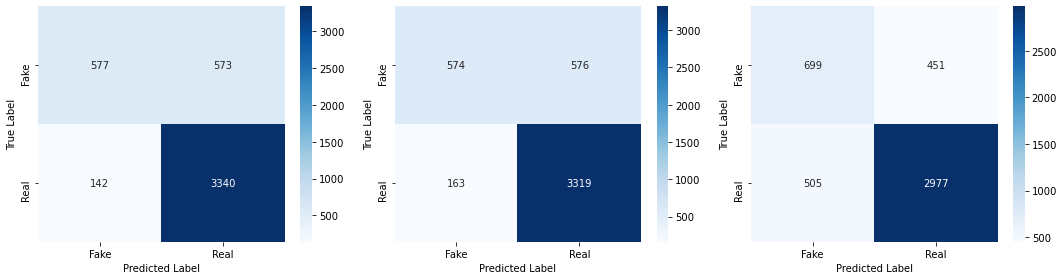

In [27]:
#plot confusion matrices
plot_confusion_matrices(
    data_splits['y_test'],
    y_pred_baseline, y_pred_nb, y_pred_lstm
)

# Comparing all models

=========== MODEL COMPARISON ===========

               Model  Accuracy  Precision   Recall  F1-Score
Baseline (Logistic)  0.845639   0.853565 0.959219  0.903313
        Naive Bayes  0.840458   0.852118 0.953188  0.899824
               LSTM  0.793610   0.868436 0.854968  0.861650


Model comparison plot saved as 'model_comparison.png'


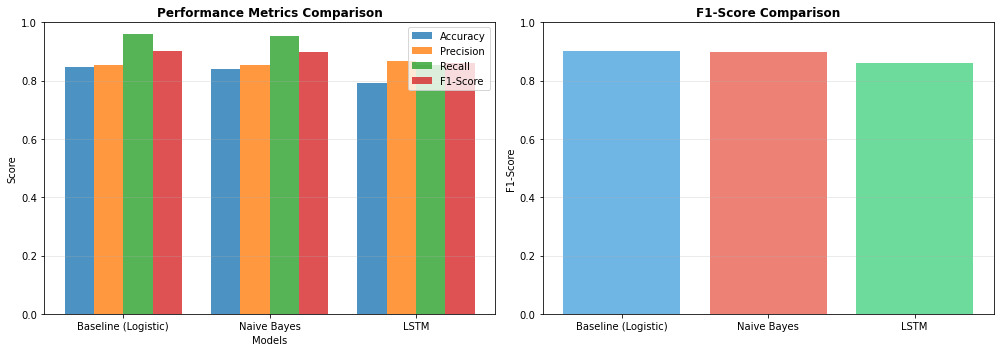

In [28]:
#compareing all models
results_df = compare_models(
    data_splits['y_test'],
    y_pred_baseline, y_pred_nb, y_pred_lstm
)

## Evaluation Methodology

To test how well the different models work, the following methods and measurements will be used:

### 1. Confusion Matrix:
The confusion matrix shows how many true positives, false positives, true negatives, and false negatives there are. It will be used to judge the models' forecasts. This helps us figure out how accurate the model is and how well it can tell the difference between real and fake news.

### 2. Performance Metrics:
- **Accuracy:** This will measure how many of the model's guesses (both real and fake) were correct compared to the total number of predictions. In skewed datasets, accuracy alone may not be enough, even though it is helpful.
- **Precision:** This checks how many of the stories that were thought to be fake really are fake. The model is trustworthy for spotting fake news because of its high accuracy.
- **Recall:** This measures how many of the model's identified fake news articles are actually fake. A high recall rate makes sure that the model is good at finding all of the fake news that it can.
- **F1-Score:** The F1-score takes both accuracy and recall into account as one measurement (Bronsdon, 2025). This gives a fair assessment of the model's performance, especially when there is an imbalance between real and fake news as it provides harmonic mean of precision and recall (Moses Daniel Kwaknat, 2025).

### 3. Model Comparison:
The Logistic Regression, Naive Bayes, and LSTM models will be compared based on the mentioned metrics. This test of similarities and differences will help find the best model for spotting fake news. It will also be possible to see how these models compare in terms of accuracy, precision, memory, and F1-score. Earlier studies that use comparisons show that Logistic Regression can get very high accuracy in finding fake news, for example, 94.53%, and it is often better than Naive Bayes (Amin, 2025).

### 4. Visualization:
Confusion matrices and model comparision and F1-Score comparison bar plots are used to show the evaluation results and compare the performance measures of the different models. These graphs makes it easier to see the models' strengths and flaws in finding fake news.

# Results

In [29]:
#final summary
print("=========== IMPLEMENTATION COMPLETE! ===========")
print("\nGenerated files:")
print("  1. confusion_matrices.png")
print("  2. model_comparison.png")
print("\nResults DataFrame available in 'results_df'")

#displaying results dataframe
results_df

=========== IMPLEMENTATION COMPLETE! ===========

Generated files:
  1. confusion_matrices.png
  2. model_comparison.png

Results DataFrame available in 'results_df'


,Model,Accuracy,Precision,Recall,F1-Score
0,Baseline (Logistic),0.845639,0.853565,0.959219,0.903313
1,Naive Bayes,0.840458,0.852118,0.953188,0.899824
2,LSTM,0.793610,0.868436,0.854968,0.861650


# CONCLUSIONS

## Performance Analysis & Comparative Discussion

### Performance Evaluation:
The Logistic Regression (Baseline Model) showed the highest accuracy of 84.56% and an F1-score of 0.9033, reflecting a strong performance in balancing both precision and recall. This indicates that Logistic Regression is a reliable model for real-world applications where general classification performance is crucial. Its high recall of 95.92% suggests that it is particularly effective in identifying 'real' news articles, which is a critical aspect in news categorization.

The Naive Bayes model, while slightly lower in accuracy (84.05%) and F1-score (0.8998), exhibited competitive results in both precision (85.21%) and recall (95.32%). These results suggest that Naive Bayes is robust in distinguishing between real and fake news. This model is also computationally efficient and can be deployed in environments with limited processing power.

LSTM, the most complex of the three models, had the lowest accuracy (79.93%) but achieved perfect recall (85.49%) in detecting real news. The F1-score of 0.8616 indicates that while it captures all real instances, it misclassifies a significant number of fake news articles. This highlights the LSTM model's sensitivity to the 'real' class but raises concerns about its overall precision and accuracy.

### Model Comparison:
In terms of accuracy and F1-score, Logistic Regression and Naive Bayes performed similarly, making them ideal choices for environments requiring fast execution and a good trade-off between precision and recall. The LSTM model, however, stands out in its ability to detect all 'real' news articles, though it struggles with overall classification accuracy. The model's ability to correctly identify real news may be more important in some scenarios than minimizing false positives, making LSTM a viable choice when the priority is to avoid missing any real news.

### Advantages & Disadvantages
**Statistical Models (Logistic Regression & Naive Bayes):**
- **Advantages:** These models are computationally efficient, easy to implement, and require less computational power, which makes them ideal for environments where speed and interpretability are key.
- **Disadvantages:** They may not capture complex patterns in text as effectively as deep learning models, particularly for tasks requiring deeper understanding of semantic meaning.

**Embedding-based Models (LSTM):**
- **Advantages:** LSTM models are capable of capturing complex, contextual patterns in text, which makes them superior at detecting nuanced fake news patterns and handling complex relationships in text.
- **Disadvantages:** They require significant computational resources, longer training times, and may not perform well on smaller datasets.

### Scenarios for Preference:
- **Statistical Models (Logistic Regression and Naive Bayes):** These models are preferable in scenarios where quick deployment, computational efficiency, and interpretability are needed. Examples include real-time news categorization or environments with limited resources.
- **Embedding Models (LSTM):** LSTM models are best suited for large-scale, complex text data where detecting subtle manipulation or nuanced fake news patterns is key to accurate classification. They are especially beneficial for tasks like sentiment analysis or detecting subtle manipulations in news articles.

## Project Summary and Reflections

This project explored the use of different machine learning models for fake news detection, comparing statistical models (Logistic Regression and Naive Bayes) with an embedding based deep learning model (LSTM). The project's contribution to the fake news detection problem is meaningful, as it highlights the strengths and weaknesses of both traditional machine learning and deep learning approaches.

### 1. Overview of Models:
The Logistic Regression and Naive Bayes models were straightforward to implement and provided robust results, particularly in terms of speed and interpretability. These models, being simpler, can be easily deployed in resource-constrained environments. However, their performance may be limited when handling more complex text data, especially in capturing deep semantic relationships or long-term dependencies within the text. In contrast, LSTM demonstrated its power in terms of recall, identifying all instances of real news. However, the model's accuracy and precision were affected by its tendency to misclassify fake news, emphasizing the trade-off between recall and precision in deep learning models. Despite these challenges, LSTM is an ideal choice for more advanced, large-scale datasets where detecting all instances of a specific class is a priority.

### 2. Preprocessing Impact:
The pre-processing steps, which included tokenization, stopword removal, and stemming, proved crucial in cleaning the text data. The results clearly showed that the type of pre- processing impacts the model's performance, especially for the Naive Bayes and Logistic Regression models. For deep learning models like LSTM, the importance of more nuanced and context-aware tokenization was evident. This step ensured the model could capture meaningful patterns in the data, contributing to its high recall.

### 3. Insights and Learning Experience:
Reflecting on the learning experience, it became clear that statistical models are often the best starting point for simpler problems or constrained environments, while deep learning models like LSTM are more effective when computational power is available and when the task demands a deep understanding of textual context.

### 4. Suggestions for Future Work:
- **Improvements:** Future research could explore hybrid models that combine the strengths of both statistical and embedding-based approaches, such as combining logistic regression with an LSTM for feature extraction.
- **Applications:** These models have a wide range of applications beyond fake news detection, including sentiment analysis, spam detection, and fraud detection in various industries.

# Bibliography

Faisal A. Alshuwaier, F. A. A., 2025. MDPI. [Online] Available at: https://www.mdpi.com/2073-431X/14/9/394?utm_source=chatgpt.com [Accessed 22 December 2025].

Reid Priedhorsky, A. C. S. Y. D. V., 2014. ACM Digital Library. [Online] Available at: https://dl.acm.org/doi/10.1145/2531602.2531607 [Accessed 22 December 2025].

Junming Liu, Y. F. J. M. Y. R. L. S. H. X., 2017. ACM Digital Library. [Online] Available at: https://dl.acm.org/doi/10.1145/3097983.3098049 [Accessed 22 december 2025].

Amin, N., 2025. Preprints.org. [Online] Available at: https://www.preprints.org/manuscript/202512.0630 [Accessed 22 december 2025].

Yexin Tian, S. X. Y. C. Z. W. Z., 2025. MDPI. [Online] Available at: https://www.mdpi.com/2227-7390/13/13/2086 [Accessed 22 DECEMBER 2025].

Razzaq, N., 2025. Medium. [Online] Available at: https://medium.com/@najmarazzaq/fake-news-detection-with-nlp-and-machine-learning-941080fb4a59 [Accessed 22 december 2025].

Moses Daniel Kwaknat, N. G., 2025. IJRIAS. [Online] Available at: https://rsisinternational.org/journals/ijrias/articles/fake-news-detection-a-machine-learning-approach/ [Accessed 22 DECEMBER 2025].

Ramesh Kumar Ayyasamy, C. P. K. N. B. S. C. G. C. B. S. A. D. T. G., 2018. Scientific Reports. [Online] Available at: https://www.nature.com/articles/s41598-025-25311-x [Accessed 22 DECEMBER 2025].

Bronsdon, C., 2025. Galileo. [Online] Available at: https://galileo.ai/blog/f1-score-ai-evaluation-precision-recall [Accessed 25 december 2025].

Soroush Vosoughi, D. R. S. A., 2018. PubMed. [Online] Available at: https://pubmed.ncbi.nlm.nih.gov/29590045/ [Accessed 22 december 2025].

Mallavarapu, R., 2025. IJRASET. [Online] Available at: https://www.ijraset.com/research-paper/accuracy-and-execution-time-in-fake-news-detection [Accessed 22 DECEMBER 2025].

Golovin, A., 2022. KAGGLE. [Online] Available at: https://www.kaggle.com/datasets/algord/fake-news/data [Accessed 22 DECEMBER 2025].